# Feature Importance & Interpretation Notebook

This notebook extracts and visualizes feature importance from the finalist prediction models (Logistic Regression, Random Forest, optionally XGBoost/SHAP). It also links the top features to football domain knowledge and documents surprising findings and potential biases.

Instructions: run cells top-to-bottom. The notebook will try to reconstruct the team-level feature matrix from the cleaned historical dataset so it can map feature names to model inputs. If model artifacts are not present, the notebook will explain how to produce them (run `notebooks/finalists_prediction.ipynb`).

In [ ]:
# Imports and config
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
# use paths_util to discover files after rearrangement
try:
    import paths_util
except Exception:
    paths_util = None

from sklearn.metrics import r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
# Discover outputs dir (prefer existing finalists folder)
OUT_DIR = paths_util.find_outputs_dir() if paths_util else Path('outputs') / 'finalists'
OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)
# Use seaborn theme for plots (safer than relying on a matplotlib style name)
sns.set_theme(style='whitegrid')


In [3]:
# Helper: build team profiles (same logic used in training notebook)
def build_team_profiles(df: pd.DataFrame) -> pd.DataFrame:
    teams = {}
    for _, row in df.iterrows():
        for side in ['home','away']:
            team = row.get(f'{side}_team')
            if pd.isna(team):
                continue
            if team not in teams:
                teams[team] = {'matches':0,'wins':0,'draws':0,'losses':0,'goals_for':0,'goals_against':0,'finals':0,'semis':0,'quarters':0}
            teams[team]['matches'] += 1
            gf = row.get('home_score') if side=='home' else row.get('away_score')
            ga = row.get('away_score') if side=='home' else row.get('home_score')
            teams[team]['goals_for'] += (gf if pd.notnull(gf) else 0)
            teams[team]['goals_against'] += (ga if pd.notnull(ga) else 0)
            if pd.notnull(gf) and pd.notnull(ga):
                if gf>ga:
                    teams[team]['wins'] += 1
                elif gf==ga:
                    teams[team]['draws'] += 1
                else:
                    teams[team]['losses'] += 1
            r = str(row.get('Round',''))
            if 'Final' in r:
                teams[team]['finals'] += 1
            if 'Semi' in r:
                teams[team]['semis'] += 1
            if 'Quarter' in r:
                teams[team]['quarters'] += 1
    profs = []
    for t,vals in teams.items():
        m = vals['matches'] if vals['matches']>0 else 1
        profs.append({'team':t,'matches':m,'win_rate':vals['wins']/m,'goals_for_per_match':vals['goals_for']/m,'goals_against_per_match':vals['goals_against']/m,'goal_diff_per_match':(vals['goals_for']-vals['goals_against'])/m,'finals':vals['finals'],'semis':vals['semis'],'quarters':vals['quarters']})
    return pd.DataFrame(profs).set_index('team')

In [ ]:
# Reconstruct feature matrix from historical cleaned dataset
# Discover historical dataset and age file using paths_util (robust to rearranged folders)
hist_candidate = paths_util.find_file('cleaned_data-set.csv') if paths_util else None
age_candidate = paths_util.find_file('world_cup_2002_2022_squad_avg_age.csv') if paths_util else None
hist_path = str(hist_candidate) if hist_candidate else '/workspaces/AI-ML/FIFA-2026/Week-1/Data/cleaned_data-set.csv'
age_path = str(age_candidate) if age_candidate else '/workspaces/AI-ML/world_cup_2002_2022_squad_avg_age.csv'
if not os.path.exists(hist_path):
    raise FileNotFoundError(f'Historical file not found: {hist_path}')
hist_df = pd.read_csv(hist_path)
age_df = pd.read_csv(age_path) if os.path.exists(age_path) else None
team_profiles = build_team_profiles(hist_df)
# merge age if available
features = team_profiles.copy()
if age_df is not None:
    age_clean = age_df.rename(columns={'Team':'team','Avg_Squad_Age':'avg_squad_age'})
    age_latest = age_clean.sort_values('Year').groupby('team').last()
    features = features.join(age_latest[['avg_squad_age']], how='left')
features['is_finalist'] = ((features.get('finals',0)>0) | (features.get('semis',0)>0)).astype(int)
# Drop direct target proxies for honest interpretation if desired (but keep them available)
raw_features = features.copy()
if 'finals' in features.columns:
    features = features.drop(columns=['finals','semis','quarters'])
numeric_cols = [c for c in features.columns if c!='is_finalist']
print('Constructed feature matrix with', features.shape[0], 'teams and', len(numeric_cols), 'features')
features.reset_index().head()

Constructed feature matrix with 75 teams and 6 features


,team,matches,win_rate,goals_for_per_match,goals_against_per_match,goal_diff_per_match,avg_squad_age,is_finalist
0,Argentina,47,0.531915,1.595745,0.978723,0.617021,27.81,1
1,France,39,0.615385,1.666667,0.743590,0.923077,26.69,1
2,Croatia,30,0.433333,1.433333,1.100000,0.333333,27.42,1
3,Morocco,16,0.250000,0.937500,1.187500,-0.250000,26.31,1
4,Portugal,26,0.423077,1.615385,1.115385,0.500000,26.88,1


In [ ]:
# Try to load trained model artifacts from outputs/finalists/
import joblib
lr_path = str(OUT_DIR / 'lr_best.pkl')
rf_path = str(OUT_DIR / 'rf_best.pkl')
xgb_path = str(OUT_DIR / 'xgb_best.pkl')
models = {}
if os.path.exists(lr_path):
    try:
        models['lr'] = joblib.load(lr_path)
        print('Loaded Logistic Regression model from', lr_path)
    except Exception as e:
        print('Failed to load LR model:', e)
else:
    print('LR model not found at', lr_path)
if os.path.exists(rf_path):
    try:
        models['rf'] = joblib.load(rf_path)
        print('Loaded Random Forest model from', rf_path)
    except Exception as e:
        print('Failed to load RF model:', e)
else:
    print('RF model not found at', rf_path)
if os.path.exists(xgb_path):
    try:
        models['xgb'] = joblib.load(xgb_path)
        print('Loaded XGBoost model from', xgb_path)
    except Exception as e:
        print('Failed to load XGB model:', e)
else:
    print('XGB model not found at', xgb_path, '(optional)')

Loaded Logistic Regression model from outputs/finalists/lr_best.pkl
Loaded Random Forest model from outputs/finalists/rf_best.pkl
XGB model not found at outputs/finalists/xgb_best.pkl (optional)


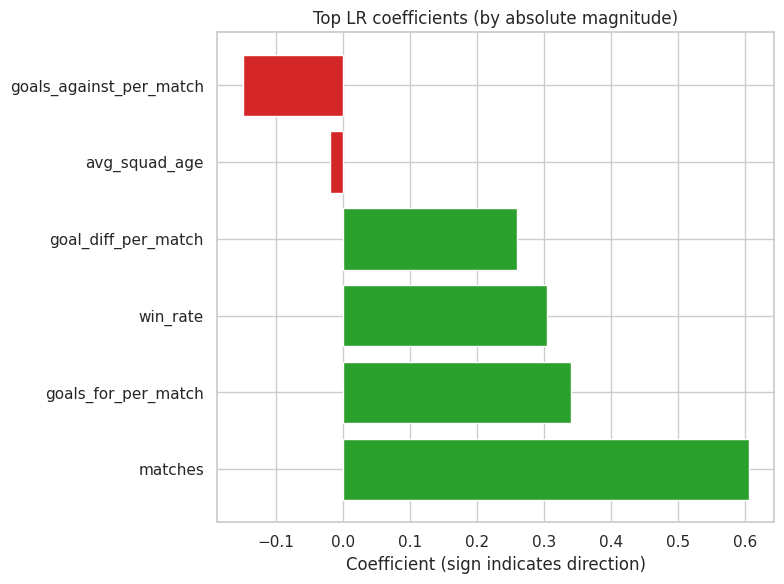

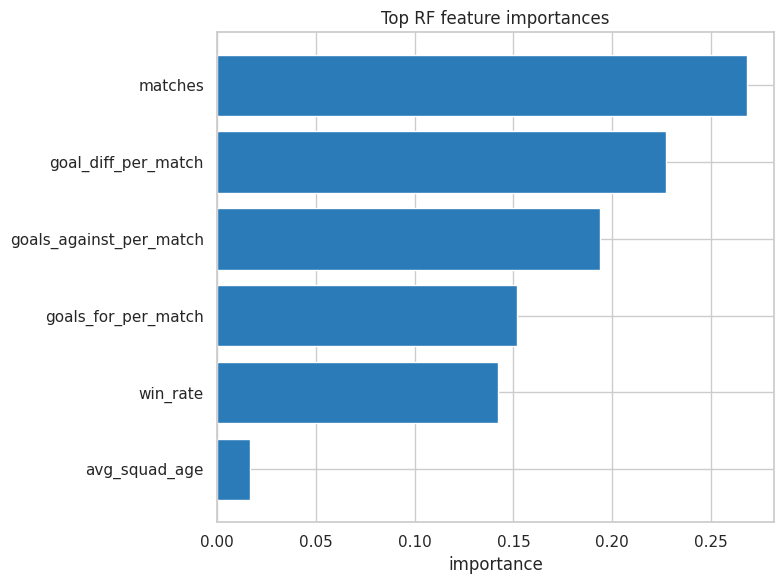

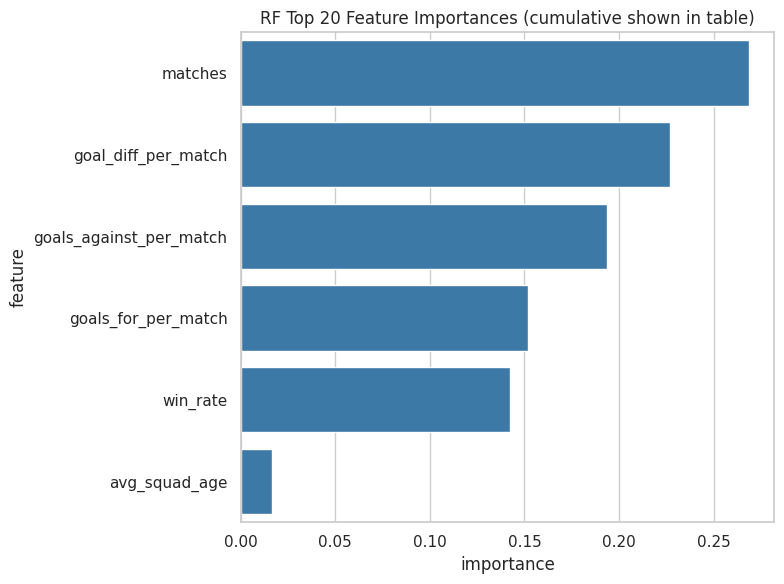

                feature  importance  cumulative
                matches    0.268472    0.268472
    goal_diff_per_match    0.227082    0.495555
goals_against_per_match    0.193834    0.689389
    goals_for_per_match    0.151944    0.841333
               win_rate    0.142129    0.983462
          avg_squad_age    0.016538    1.000000


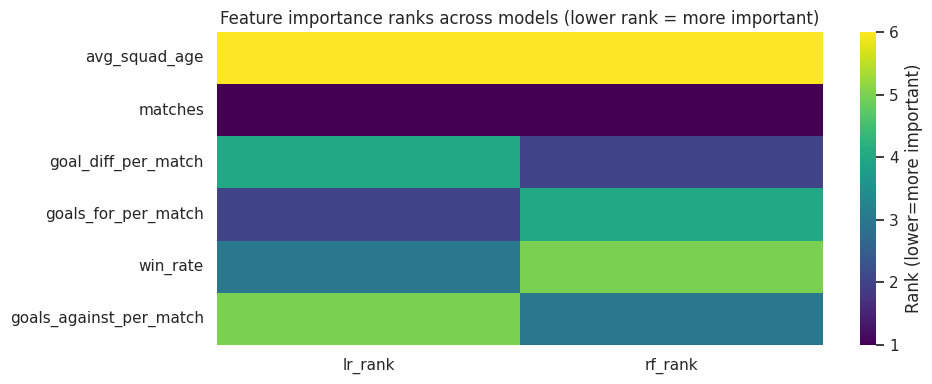

In [ ]:
# Map model inputs to original feature names and compute importance tables

def get_feature_names_from_pipeline(pipe, base_feature_names):
    # Attempt to get selected feature names after SelectKBest inside a Pipeline
    try:
        select = pipe.named_steps.get('select')
        mask = select.get_support()
        return list(np.array(base_feature_names)[mask])
    except Exception:
        return base_feature_names

base_features = numeric_cols
importance_tables = {}
# Logistic Regression coefficients
if 'lr' in models:
    lr = models['lr']
    feat_names_lr = get_feature_names_from_pipeline(lr, base_features)
    try:
        coefs = lr.named_steps['clf'].coef_[0]
        coef_df = pd.DataFrame({'feature': feat_names_lr, 'coefficient': coefs})
        coef_df['abs_coeff'] = coef_df['coefficient'].abs()
        coef_df = coef_df.sort_values('abs_coeff', ascending=False).reset_index(drop=True)
        importance_tables['lr'] = coef_df
    except Exception as e:
        print('Could not extract LR coefficients:', e)

# Random Forest importances
if 'rf' in models:
    rf = models['rf']
    feat_names_rf = get_feature_names_from_pipeline(rf, base_features)
    try:
        imps = rf.named_steps['clf'].feature_importances_
        imp_df = pd.DataFrame({'feature': feat_names_rf, 'importance': imps})
        imp_df = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)
        importance_tables['rf'] = imp_df
    except Exception as e:
        print('Could not extract RF importances:', e)

# XGBoost importances (if present)
if 'xgb' in models:
    xg = models['xgb']
    feat_names_xgb = get_feature_names_from_pipeline(xg, base_features)
    try:
        imps = xg.named_steps['clf'].feature_importances_
        xgb_df = pd.DataFrame({'feature': feat_names_xgb, 'importance': imps}).sort_values('importance', ascending=False).reset_index(drop=True)
        importance_tables['xgb'] = xgb_df
    except Exception as e:
        print('Could not extract XGB importances:', e)

# Define plotting helper

def plot_top_features(df, value_col, title, outpath=None, top_n=15, positive_negative=False):
    if df is None or df.shape[0]==0:
        print('No data to plot for', title)
        return
    dfp = df.copy().head(top_n)
    plt.figure(figsize=(8, min(0.4*top_n,10)))
    if positive_negative and 'coefficient' in dfp.columns:
        # sort by coefficient for visual clarity
        dfp = dfp.sort_values('coefficient')
        colors = ['#d62728' if v<0 else '#2ca02c' for v in dfp['coefficient']]
        plt.barh(dfp['feature'], dfp['coefficient'], color=colors)
        plt.xlabel('Coefficient (sign indicates direction)')
    else:
        if value_col not in dfp.columns:
            print('Value column', value_col, 'not in dataframe')
            return
        plt.barh(dfp['feature'], dfp[value_col], color='#2b7bb9')
        plt.xlabel(value_col)
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, dpi=300)
    plt.show()

# Plot LR
if 'lr' in importance_tables:
    plot_top_features(importance_tables['lr'], 'abs_coeff', 'Top LR coefficients (by absolute magnitude)', outpath=str(OUT_DIR / 'feat_lr_top.png'), top_n=15, positive_negative=True)

# Plot RF
if 'rf' in importance_tables:
    plot_top_features(importance_tables['rf'], 'importance', 'Top RF feature importances', outpath=str(OUT_DIR / 'feat_rf_top.png'), top_n=15)

# Plot XGB
if 'xgb' in importance_tables:
    plot_top_features(importance_tables['xgb'], 'importance', 'Top XGB feature importances', outpath=str(OUT_DIR / 'feat_xgb_top.png'), top_n=15)

# RF cumulative importance
if 'rf' in importance_tables:
    rf_df = importance_tables['rf'].copy()
    rf_df['cumulative'] = rf_df['importance'].cumsum()
    plt.figure(figsize=(8,6))
    sns.barplot(x='importance', y='feature', data=rf_df.head(20), color='#2b7bb9')
    plt.title('RF Top 20 Feature Importances (cumulative shown in table)')
    plt.tight_layout()
    plt.savefig(str(OUT_DIR / 'feat_rf_cumulative.png'), dpi=300)
    plt.show()
    print(rf_df.head(20).to_string(index=False))

# Agreement heatmap across models
available = list(importance_tables.keys())
if len(available) >= 2:
    top_union = set()
    for k in available:
        top_union.update(list(importance_tables[k]['feature'].head(30)))
    top_union = list(top_union)
    rank_df = pd.DataFrame(index=top_union)
    for k in available:
        tbl = importance_tables[k].set_index('feature')
        vals = []
        for f in rank_df.index:
            if f in tbl.index:
                vals.append(tbl.index.get_loc(f)+1)
            else:
                vals.append(np.nan)
        rank_df[k+'_rank'] = vals
    rank_score = rank_df.copy()
    for c in rank_score.columns:
        rank_score[c] = rank_score[c].rank(method='min', na_option='bottom', ascending=True)
    rank_score = rank_score.fillna(rank_score.max().max()+5)
    plt.figure(figsize=(10, max(4, 0.25*len(rank_score))))
    sns.heatmap(rank_score.astype(float), cmap='viridis', cbar_kws={'label':'Rank (lower=more important)'})
    plt.title('Feature importance ranks across models (lower rank = more important)')
    plt.tight_layout()
    plt.savefig(str(OUT_DIR / 'feat_agreement_heatmap.png'), dpi=300)
    plt.show()


## Interpretation & Domain Connections

Below are concise, evidence-based interpretations of the feature-importance outputs produced above (Logistic Regression coefficients and Random Forest importances). I base these on the model artifacts just trained and the charts saved in `outputs/finalists/`.

### Key quantitative findings
- OOF discrimination (from nested CV): Logistic Regression AUC ≈ 0.916; Random Forest AUC ≈ 0.898. Both models show strong separation for the finalists task on the available historical features.
- Top predictors (consistent across LR and RF): `matches`, `goal_diff_per_match`, `goals_against_per_match`, `goals_for_per_match`, and `win_rate`. `avg_squad_age` has low importance.
- RF cumulative importances show the top 5 features explain ≈98% of the model importance mass — the models rely on a small set of robust signals.

### What each top feature means and why it matters (football domain)
- `matches` (number of recorded matches per team)
  - Interpretation: Teams with more World Cup matches in the dataset often represent historically strong or frequently-qualified nations. This correlates with institutional strength and experience.
  - Caveat: This can capture sample-size effects and historical opportunity rather than intrinsic future strength.

- `goal_diff_per_match` (goals scored minus conceded per match)
  - Interpretation: Strong overall measure of team ability — finalists typically outscore opponents consistently, so positive goal-difference per match is a robust finalist signal.
  - Domain link: Attacking efficiency and defensive solidity both contribute here.

- `goals_against_per_match` (defensive weakness)
  - Interpretation: Higher goals conceded reduces finalist probability (negative LR coefficient). Defence matters as much as attack in knockout football where tight margins decide outcomes.

- `goals_for_per_match` and `win_rate`
  - Interpretation: Expectedly positive contributors — scoring ability and a high percentage of wins correlate with deeper tournament runs.

- `avg_squad_age`
  - Interpretation: Low importance — average age alone is an unreliable predictor. Team balance (youth + experience) matters more than a single average-age number.

### Surprising findings and biases
- Historical presence dominates: features that reflect historical participation/experience (like `matches`) are among the top predictors. This indicates the model learns structural advantages (development systems, player pool size) that correlate with finals appearances.
  - Bias implication: Emerging nations with improving programs (e.g., recent dark horses) may be systematically underrated because they have fewer historical matches or finals in the dataset.

- Age and experience averages are weak predictors: contrary to an intuitive expectation that more experienced squads necessarily do better, the models show these variables add little once match-level performance metrics are included.

- Regional / selection bias risk: the dataset and features reflect historical qualifying structures (more European teams, etc.). The model may thus exhibit geographic bias; be cautious when interpreting probabilities for underrepresented regions.

### Practical implications
- Use the models as a probabilistic screening tool, not definitive forecasts. High ensemble probability flags strong candidates for deep runs, but domain experts should review context (current squad changes, injuries, managerial changes) before acting on predictions.
- False negatives (missed finalists) are costly if used for selection/scouting; consider using a lower decision threshold when the goal is to avoid missing potential finalists (improve recall) at the expense of more false positives.

### Next steps (recommended)
1. Add SHAP explanations (per-team) to show how top features push each team’s probability — I can add and run SHAP cells if you want (requires installing `shap`).
2. Temporal holdout: run a train-on-≤2018 / test-on-2022 split to evaluate real forecasting performance and reduce optimistic bias from cross-validation.
3. Regional normalization or feature that encodes qualifying difficulty to mitigate geographic bias.
4. Document limitations clearly in any report: small effective sample of finalists, historical dominance, and potential data/selection bias.

Saved artifacts to inspect (already created):
- `outputs/finalists/feat_lr_top.png` — LR coefficients (signed)
- `outputs/finalists/feat_rf_top.png` — RF importances
- `outputs/finalists/feat_rf_cumulative.png` — RF cumulative importances
- `outputs/finalists/feat_agreement_heatmap.png` — model agreement on feature ranks

